# Green Space vs Air Quality Analysis

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [19]:
df = pd.read_csv('../Data/final/environment_data.csv')
df.head()

,City,Date,PM2.5,PM10,O3,NO2,CO,SO2,Green_Space,Temperature_mean,Temperature_max,Humidity,Wind_speed,Pressure,Electricity Consumption,isWeekend,Season
0,Cairo,2023-01-01,36.337500,60.341667,33.333333,36.100000,337.416667,34.795833,53,15.888889,20.0,75.333333,8.511111,1007.247111,1.116235e+10,0,Winter
1,Cairo,2023-01-02,49.379167,78.937500,18.625000,46.704167,442.000000,55.141667,53,16.044444,21.0,70.844444,7.888889,1006.393556,1.116235e+10,0,Winter
2,Cairo,2023-01-03,34.066667,51.825000,24.583333,44.612500,387.041667,48.670833,53,15.288889,19.0,75.911111,6.644444,1006.458667,1.116235e+10,0,Winter
3,Cairo,2023-01-04,30.737500,43.029167,38.958333,37.420833,322.166667,42.025000,53,15.777778,19.0,78.377778,7.022222,1007.377111,1.116235e+10,0,Winter
4,Cairo,2023-01-05,23.145833,34.125000,29.041667,48.162500,415.166667,50.412500,53,16.136364,19.0,61.795455,5.704545,1008.101818,1.116235e+10,0,Winter


In [12]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 2548 entries, 0 to 2547
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   City                     2548 non-null   str    
 1   Date                     2548 non-null   str    
 2   PM2.5                    2548 non-null   float64
 3   PM10                     2548 non-null   float64
 4   O3                       2548 non-null   float64
 5   NO2                      2548 non-null   float64
 6   CO                       2548 non-null   float64
 7   SO2                      2548 non-null   float64
 8   Green_Space              2548 non-null   int64  
 9   Temperature_mean         2548 non-null   float64
 10  Temperature_max          2548 non-null   float64
 11  Humidity                 2548 non-null   float64
 12  Wind_speed               2548 non-null   float64
 13  Pressure                 2548 non-null   float64
 14  Electricity Consumption  2548 non-n

,PM2.5,PM10,O3,NO2,CO,SO2,Green_Space,Temperature_mean,Temperature_max,Humidity,Wind_speed,Pressure,Electricity Consumption,isWeekend
count,2548.000000,2548.000000,2548.000000,2548.000000,2548.000000,2548.000000,2548.000000,2548.000000,2548.000000,2548.000000,2548.000000,2548.000000,2.548000e+03,2548.000000
mean,20.417589,37.057589,54.534161,33.155532,338.559409,14.461962,105.139717,19.034251,23.260204,64.620222,13.672576,984.927908,1.612599e+10,0.286892
std,14.069021,36.686546,26.078559,23.776493,219.605313,17.562906,46.006487,8.417289,9.220257,15.053140,5.369632,59.903467,1.340650e+10,0.452399
min,2.887500,4.166667,1.416667,1.841667,111.125000,0.200000,51.000000,-8.681818,-3.000000,16.560000,2.000000,835.370000,1.120659e+09,0.000000
25%,9.403125,14.604167,37.541667,15.887500,204.812500,3.207292,53.000000,12.661458,16.000000,54.520833,9.958333,997.455260,8.342517e+09,0.000000
50%,16.943750,25.450000,53.250000,27.539583,278.895833,6.202083,120.000000,19.465000,24.000000,65.000000,12.750000,1007.051963,1.155248e+10,0.000000
75%,26.831250,43.475000,69.354167,44.290625,400.572917,22.671875,162.000000,24.333333,29.000000,76.306738,16.196314,1014.756474,1.859523e+10,1.000000
max,91.745833,348.716667,220.333333,180.391667,2661.125000,157.254167,164.000000,40.625000,71.000000,97.625000,46.916667,1041.341875,5.359646e+10,1.000000


## Correlation Heatmap

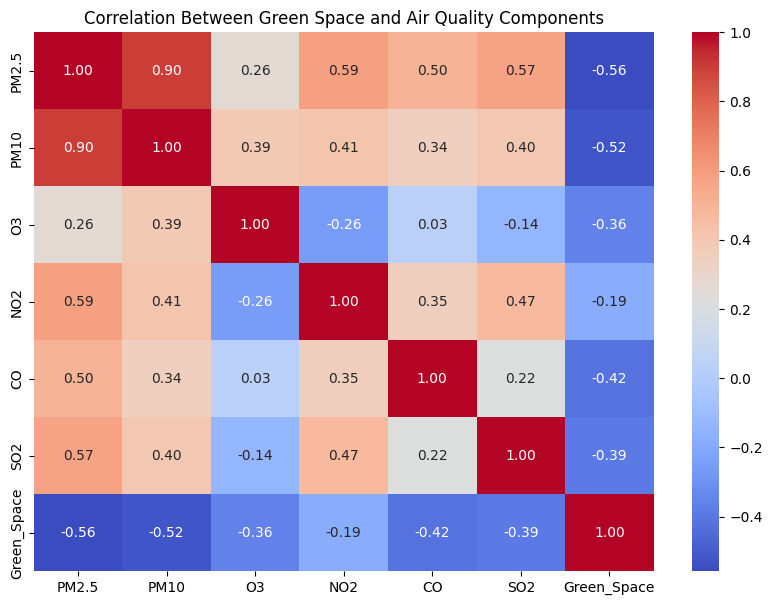

In [13]:
corr_matrix = df[['PM2.5', 'PM10', 'O3', 'NO2', 'CO', 'SO2', 'Green_Space']].corr()

plt.figure(figsize=(10,7))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Between Green Space and Air Quality Components')
plt.show()


Negative correlations between green space and pollutants may indicate that cities with more green areas experience better air quality.

Strong positive correlations between pollutants suggest polluted cities often experience multiple pollutants simultaneously.

## Scatter Plots: Green Space vs Air Pollutants

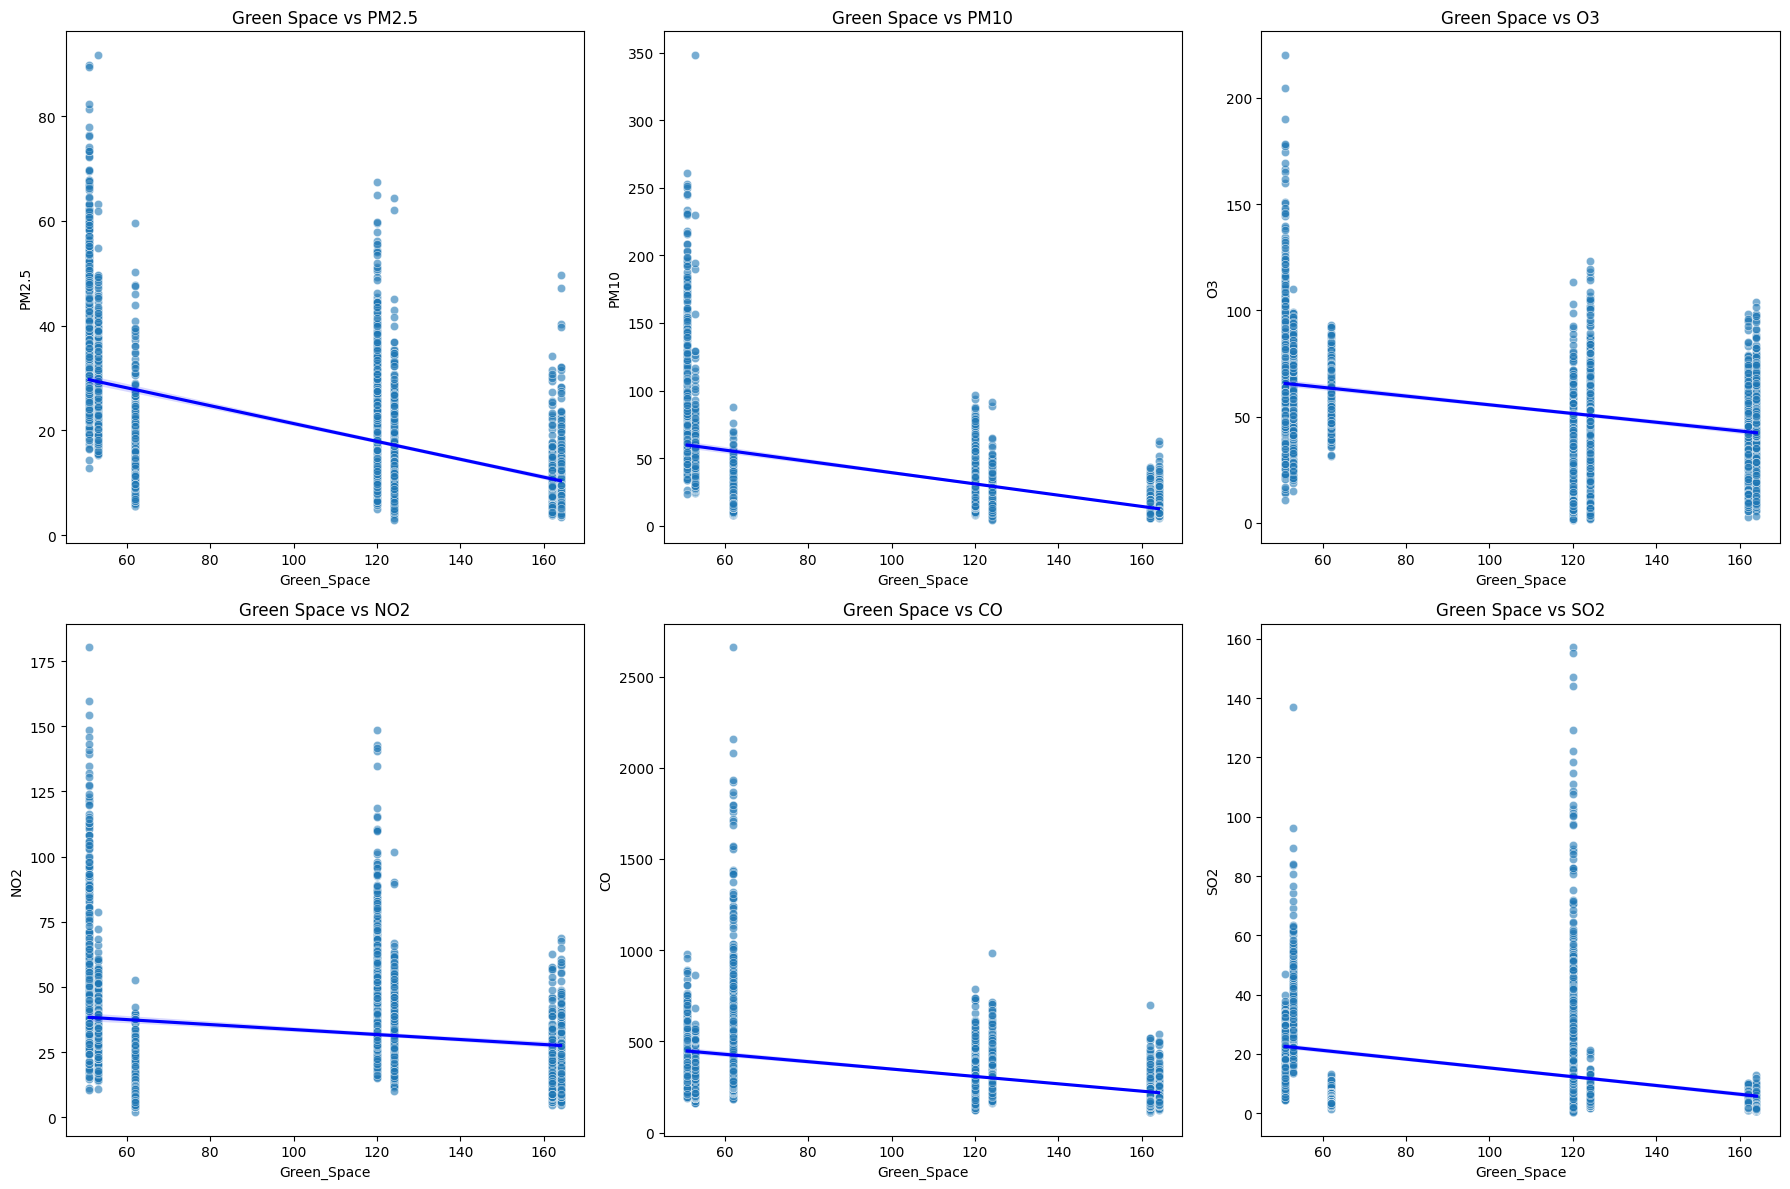

In [14]:
pollutants = ['PM2.5', 'PM10', 'O3', 'NO2', 'CO', 'SO2']

plt.figure(figsize=(18,12))

for i, pollutant in enumerate(pollutants, 1):
    plt.subplot(2,3,i)
    sns.scatterplot(data=df, x='Green_Space', y=pollutant, alpha=0.6)
    sns.regplot(data=df, x='Green_Space', y=pollutant, scatter=False, color='blue')
    plt.title(f'Green Space vs {pollutant}')

plt.tight_layout()
plt.show()


In most cases, higher green space coverage appears associated with lower pollutant concentrations.

## Average Pollutant Levels by City

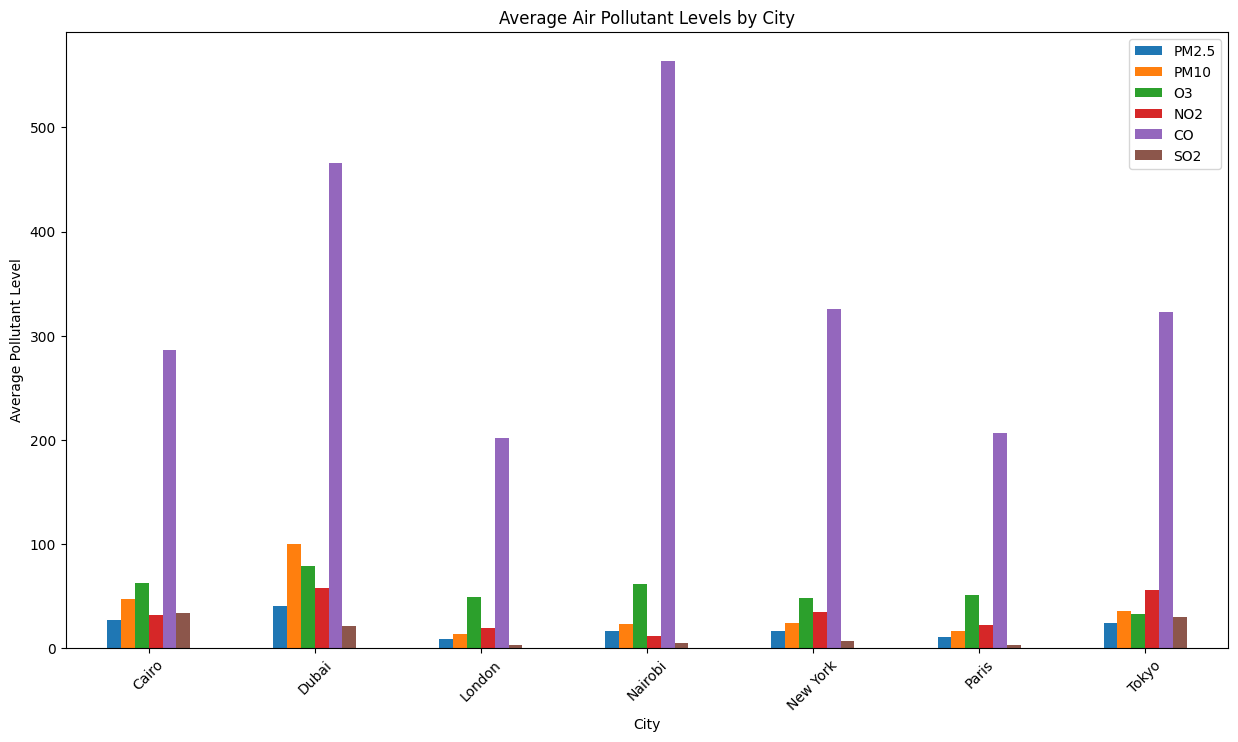

In [15]:
city_avg = df.groupby('City')[['PM2.5', 'PM10', 'O3', 'NO2', 'CO', 'SO2']].mean()

city_avg.plot(kind='bar', figsize=(15,8))
plt.title('Average Air Pollutant Levels by City')
plt.ylabel('Average Pollutant Level')
plt.xticks(rotation=45)
plt.show()


Some cities show higher pollution levels across multiple pollutants, indicating worse overall air quality.


## PCA of Air Quality Components

In [20]:
pollutants = ['PM2.5', 'PM10', 'O3', 'NO2', 'CO', 'SO2']

scaler = StandardScaler()
scaled_pollutants = scaler.fit_transform(df[pollutants])

pca = PCA(n_components=2)
pca_components = pca.fit_transform(scaled_pollutants)


df['PC1'] = pca_components[:, 0]
df['PC2'] = pca_components[:, 1]

print('Explained Variance Ratio:', pca.explained_variance_ratio_)

Explained Variance Ratio: [0.49662732 0.22992342]


PCA combines all pollutant variables into two main components:
PC1 captures the largest variation in air pollution.
PC2 captures the second largest variation.

## Green Space vs PCA

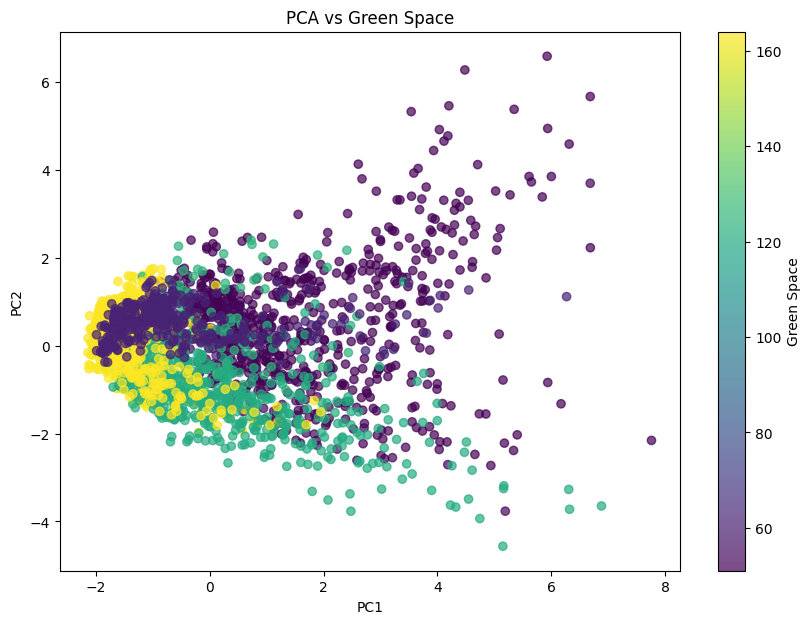

In [21]:
plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    df['PC1'],
    df['PC2'],
    c=df['Green_Space'],
    cmap='viridis',
    alpha=0.7
)

plt.colorbar(scatter, label='Green Space')

plt.title('PCA vs Green Space')
plt.xlabel('PC1')
plt.ylabel('PC2')

plt.show()

The PCA scatter plot visualizes cities based on overall pollution patterns. Cities with similar pollution characteristics cluster together.
The color scale represents green space coverage, helping identify whether greener cities tend to appear in lower pollution regions of the PCA space.

# Final Conclusion

- Several pollutants show negative relationships with green space.
- Cities with larger green areas often demonstrate lower pollution levels.
- The combined air quality score generally decreases as green space increases.
- Air pollutants tend to rise together in heavily polluted cities.

Overall, increasing urban green space may contribute to healthier environmental conditions and reduced air pollution exposure.